<a href="https://colab.research.google.com/github/jaxendutta/emma/blob/main/notebooks/04_rag_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04: RAG Pipeline

## Goal

Wire all components from Notebooks 01-03 into a single end-to-end pipeline and answer the project's central research question:

> Does textbook-grounded RAG improve small LLM accuracy on MedQA compared to a baseline without retrieval?

## Pipeline Stages
```
Raw query
  -> SpaCy NER (en_core_sci_md)          extract clinical entities
  -> Query rewriting                     entity string replaces full vignette
  -> FAISS retrieval (vectorstore)       top-k textbook chunks + confidence
  -> Specialty classifier                predict domain for prompt context
  -> Prompt construction                 structured prompt with hedging
  -> Ollama LLM                          grounded answer
```

## Evaluation

Each question answered twice (RAG and baseline). Accuracy on the 4-option multiple choice is the primary metric. Secondary: retrieval quality, NER extraction quality, latency per condition.

## Benchmark Target

AMG-RAG reports 66.34% accuracy on MedQA.

## Output
```
models/rag/
  results.parquet   <- per-question results (RAG + baseline)
  config.json       <- pipeline settings and aggregate metrics
```

## 0. Setup

In [ ]:
# Imports
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from src.data import REPO_ROOT, load_medqa
from src.retrieval import EMMARetriever, extract_entities, rewrite_query

warnings.filterwarnings('ignore')

RAG_DIR = REPO_ROOT / 'models' / 'rag'
RAG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root : {REPO_ROOT}')
print(f'RAG dir   : {RAG_DIR}')

In [1]:
# ── COLAB ONLY — skip if running locally ─────────────────────────────────────
# Requires in Colab Secrets (key icon in sidebar):
#   GITHUB_REPO_URL  : your repo clone URL
#   HF_TOKEN         : huggingface.co/settings/tokens
#                      (required for MedGemma, Gemma 3, Ministral)
#
# Accept gated model terms BEFORE running (one-time, free):
#   MedGemma : https://huggingface.co/google/medgemma-4b-it
#   Gemma 3  : https://huggingface.co/google/gemma-3-4b-it
#   Ministral: https://huggingface.co/mistralai/Ministral-3B-Instruct-2410
# -----------------------------------------------------------------------------

import os, shutil
from pathlib import Path
from google.colab import drive, userdata

HF_TOKEN = userdata.get('HF_TOKEN')
if not Path('/content/emma').exists():
    !git clone https://github.com/jaxendutta/emma.git
os.chdir('/content/emma')
!pip install -e . -q
!pip install transformers accelerate bitsandbytes faiss-cpu sentence-transformers -q
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz -q

drive.mount('/content/drive')
DRIVE_BASE = Path('/content/drive/MyDrive/emma/models')
DRIVE_OUT  = DRIVE_BASE / 'rag'
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

# Restore upstream model artifacts from Drive
# These are produced by notebooks 01-03 and saved to Drive at their end.
for artifact in ['vectorstore', 'classifier', 'clustering']:
    src_dir = DRIVE_BASE / artifact
    dst_dir = Path(f'/content/emma/models/{artifact}')
    dst_dir.mkdir(parents=True, exist_ok=True)
    for f in src_dir.glob('*'):
        if f.is_file():
            shutil.copy(f, dst_dir / f.name)
    print(f'✓ Restored {artifact}: {[f.name for f in dst_dir.glob("*")]}')

import json, re, warnings
import matplotlib.pyplot as plt, numpy as np, pandas as pd
from tqdm import tqdm
from src.data import REPO_ROOT, load_medqa
from src.retrieval import EMMARetriever, extract_entities, rewrite_query, list_models
warnings.filterwarnings('ignore')
RAG_DIR = REPO_ROOT / 'models' / 'rag'
RAG_DIR.mkdir(parents=True, exist_ok=True)
print('✓ Colab setup complete.')

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for emma (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Restored vectorstore: ['metadata.pkl', 'texts.pkl', 'config.json', 'index.faiss']
✓ Restored classifier: ['label_encoder.pkl', 'config.json', 'tfidf_svm.pkl', 'medqa_with_specialty.parquet']
✓ Restored clustering: ['bertopic_model', 'config.json', 'medqa_with_topics.parquet']
✓ Colab setup complete.


## 1. Load Pipeline

Loads all pre-built components: FAISS vectorstore, specialty classifier, SpaCy NER.
Fails with clear error messages if any model file is missing.

In [2]:
import os
from src.retrieval import list_models, get_default_model_id

# HF token -- needed for gated models (MedGemma, Gemma 3, Ministral)
# Set via environment variable or paste directly (do not commit to git)
HF_TOKEN = os.environ.get('HF_TOKEN', '')   # or: HF_TOKEN = 'hf_...'

# All models from config/models.json
models = list_models()
print(f'Models in evaluation lineup ({len(models)}):')
for m in models:
    ranked = f"Medmarks #{m['medmarks_rank']} (win rate {m['medmarks_win_rate']})" if m['medmarks_rank'] else 'Not ranked'
    gated  = ' [GATED - HF token required]' if m['gated'] else ''
    print(f"  {m['id']:<20s}  {m['name']:<25s}  {ranked}{gated}")

# Load pipeline with default model (qwen3-4b per models.json)
retriever = EMMARetriever.load(hf_token=HF_TOKEN or None)
print(f'\nDefault model : {retriever.model_id}')
print(f'Top-k         : {retriever.top_k}')
print(f'Index         : {retriever.index.ntotal:,} vectors')

Models in evaluation lineup (5):
  qwen3-4b              Qwen3 4B (Thinking)        Medmarks #33 (win rate 0.4918)
  ministral-3b          Ministral 3B               Medmarks #47 (win rate 0.4173) [GATED - HF token required]
  medgemma-4b           MedGemma 4B                Medmarks #51 (win rate 0.3586) [GATED - HF token required]
  gemma3-4b             Gemma 3 4B                 Medmarks #55 (win rate 0.3202) [GATED - HF token required]
  phi4-mini             Phi-4 Mini [3.8B]          Not ranked
Loading vectorstore...
[Vectorstore] Loaded index: 36,723 vectors from /content/emma/models/vectorstore
[Vectorstore] Loaded 36,723 chunk texts from /content/emma/models/vectorstore
Loading embedding model...
[Vectorstore] GPU memory: 14.5 GB free / 14.6 GB total


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

[Vectorstore] Embedding model: Qwen/Qwen3-Embedding-0.6B  (dtype=torch.float16, device=cuda)
Loading specialty classifier...
Loading SpaCy NER model...
EMMA retriever ready. Model: qwen3-4b

Default model : qwen3-4b
Top-k         : 5
Index         : 36,723 vectors


## 2. NER Smoke Test

Verify entity extraction on a few representative query types before running the full pipeline.

In [3]:
test_queries = [
    "What is the mechanism of anaphylaxis?",
    "A 45-year-old man presents with chest pain, diaphoresis, and ST elevation in leads II, III, aVF.",
    "What are the side effects of metformin in type 2 diabetes?",
    "A child presents with inspiratory stridor, fever, and a barking cough. What is the treatment?",
]

print('NER extraction results')
print('=' * 70)
ner_rows = []
for q in test_queries:
    ents      = extract_entities(q, retriever.nlp)
    rewritten = rewrite_query(q, ents)
    ner_rows.append({
        'Query (truncated)': q[:70],
        'Entities':          ents,
        'Rewrite applied':   rewritten != q,
        'Rewritten query':   rewritten[:70],
    })

display(pd.DataFrame(ner_rows))

NER extraction results


,Query (truncated),Entities,Rewrite applied,Rewritten query
0,What is the mechanism of anaphylaxis?,"[mechanism, anaphylaxis]",True,mechanism anaphylaxis
1,"A 45-year-old man presents with chest pain, di...","[man, chest pain, diaphoresis, ST, elevation, ...",True,man chest pain diaphoresis ST elevation III aVF
2,What are the side effects of metformin in type...,"[side effects, metformin, type 2 diabetes]",True,side effects metformin type 2 diabetes
3,"A child presents with inspiratory stridor, fev...","[child, inspiratory stridor, fever, barking co...",True,child inspiratory stridor fever barking cough ...


## 3. Retrieval Smoke Test

In [4]:
# Direct question
q = "What is the mechanism of anaphylaxis?"
entities, rewritten, specialty, chunks = retriever.retrieve(q)

print(f'Query     : {q}')
print(f'Entities  : {entities}')
print(f'Rewritten : {rewritten}')
print(f'Specialty : {specialty}')
print(f'\nChunks retrieved: {len(chunks)}')
for c in chunks:
    print(f'  [{c.confidence:8s}]  score={c.score:.4f}  {c.book}')
    print(f'             {c.text[:100].strip()}...')

Query     : What is the mechanism of anaphylaxis?
Entities  : ['mechanism', 'anaphylaxis']
Rewritten : mechanism anaphylaxis
Specialty : Pathology

Chunks retrieved: 5
  [high    ]  score=0.7113  Harrison's Internal Medicine
             to beef, lamb, and pork. Individuals differ in the time of appearance of symptoms and signs, buttheh...
  [high    ]  score=0.7102  Janeway's Immunology
             Interaction of the autoantibody with the receptor triggers mast-cell degranulation, with resulting u...
  [high    ]  score=0.7089  Harrison's Internal Medicine
             seems likely. Vascular collapse without respiratory distress in response to experimental challenge w...
  [high    ]  score=0.7043  Nelson Pediatrics
             but some males have been reported in the literature. Three products are approved to treat HAE attack...
  [high    ]  score=0.7002  Harrison's Internal Medicine
             systemic anaphylactic reactions. Gastrointestinal manifestations include nausea, vomi

In [5]:
# Clinical vignette -- test NER rewriting
vignette = (
    "A 58-year-old man with hypertension presents with crushing chest pain "
    "radiating to the left arm and diaphoresis. ECG shows ST elevation in V1-V4. "
    "What is the most appropriate immediate management?"
)
entities, rewritten, specialty, chunks = retriever.retrieve(vignette)

print('Clinical vignette:')
print(f'Entities  : {entities}')
print(f'Rewritten : {rewritten}')
print(f'Specialty : {specialty}')
print(f'Chunks    : {len(chunks)}')
for c in chunks:
    print(f'  [{c.confidence:8s}]  score={c.score:.4f}  {c.book}')

Clinical vignette:
Entities  : ['man', 'hypertension', 'crushing chest pain', 'left arm', 'diaphoresis', 'ECG', 'ST', 'elevation', 'management']
Rewritten : man hypertension crushing chest pain left arm diaphoresis ECG ST elevation management
Specialty : Internal Medicine
Chunks    : 5
  [medium  ]  score=0.6025  First Aid Step 2
  [medium  ]  score=0.6024  Harrison's Internal Medicine
  [medium  ]  score=0.5944  First Aid Step 2
  [medium  ]  score=0.5858  Harrison's Internal Medicine
  [medium  ]  score=0.5807  Katzung Pharmacology


## 4. End-to-End Demo

Single question with and without RAG, side by side.

In [6]:
demo_q = "What is the mechanism of action of beta blockers in heart failure?"

rag_result, base_result = retriever.compare(demo_q)

print('=' * 70)
print('WITH RAG')
print('=' * 70)
print(f'Entities  : {rag_result.entities}')
print(f'Specialty : {rag_result.specialty}')
print(f'Chunks    : {rag_result.metadata["n_chunks_retrieved"]}  '
      f'top score={rag_result.metadata["top_score"]:.4f}  '
      f'confidence={rag_result.metadata["top_confidence"]}')
print(f'Latency   : {rag_result.latency_s:.1f}s')
print(f'\nAnswer:\n{rag_result.answer}')

print('\n' + '=' * 70)
print('WITHOUT RAG (baseline)')
print('=' * 70)
print(f'Latency   : {base_result.latency_s:.1f}s')
print(f'\nAnswer:\n{base_result.answer}')

Loading Qwen3 4B (Thinking) (Qwen/Qwen3-4B) in 4-bit nf4...
  GPU: Tesla T4  (14.6 GB VRAM)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  Loaded on cuda:0. VRAM used: 3.6 GB
WITH RAG
Entities  : ['mechanism', 'beta blockers', 'heart failure']
Specialty : Pharmacology
Chunks    : 5  top score=0.7325  confidence=high
Latency   : 91.3s

Answer:
<think>
Okay, let's tackle this question about the mechanism of action of beta blockers in heart failure. The user wants a clear and accurate answer based on the provided passages.

First, I need to recall what beta blockers do in heart failure. From the sources, there's mention of several mechanisms. Let me check the passages again.

Looking at Source 1: It says beta blockers reduce mortality in chronic heart failure by possibly affecting myocardial remodeling and decreasing sudden death risk. Also, they slow ventricular response in arrhythmias by increasing AV nodal refractory period. They can reduce ventricular ectopic beats, especially those caused by catecholamines. Also, they increase stroke volume in some patients with obstructive cardiomyopathy by slowing ejection and decre

In [7]:
# Inspect the full RAG prompt
print('FULL RAG PROMPT')
print('-' * 70)
print(rag_result.prompt)

FULL RAG PROMPT
----------------------------------------------------------------------
You are EMMA, an Emergency Medicine Mentoring Agent helping medical students study for the USMLE. You answer questions accurately and concisely, grounded in the provided textbook passages when available. If you are uncertain, say so clearly rather than guessing.

Clinical entities identified: mechanism, beta blockers, heart failure
Predicted specialty: Pharmacology

Relevant textbook passages:

[Source 1: Katzung Pharmacology | confidence: high | score: 0.732]
Massachusetts Medical Society.) moderate or severe left ventricular failure, shock, heart block, and active airways disease. It has been suggested that certain polymorphisms in β2-adrenoceptor genes may influence survival among patients receiving antagonists after acute coronary syndromes. Beta antagonists are often effective in the treatment of both supraventricular and ventricular arrhythmias (see Chapter 14). It has been suggested that the i

## 5. Batch Evaluation on MedQA Test Set

Run RAG vs baseline on a sample of MedQA test questions.
Accuracy = fraction of questions where the LLM selects the correct option (A/B/C/D).

<div class="alert alert-block alert-info">
<b style="font-size: 1.25rem;">ⓘ Note</b>

`N_EVAL = 50` for a quick run, 200+ for a reliable estimate.
AMG-RAG's reference score uses 100 questions.
</div>

In [10]:
N_EVAL      = 20    # notebook 04 = pipeline validation only
RANDOM_SEED = 42

medqa_test = load_medqa(split='test')
eval_df    = medqa_test.sample(
    n=min(N_EVAL, len(medqa_test)), random_state=RANDOM_SEED
).reset_index(drop=True)

# Notebook 04: validate pipeline with default model only
# Full 5-model grid runs in notebook 06 (evaluation benchmark)
models_for_this_nb = [next(m for m in list_models() if m['id'] == get_default_model_id())]
print(f'Questions    : {len(eval_df)}')
print(f'Model        : {models_for_this_nb[0]["name"]}')
print(f'Total calls  : {len(eval_df) * 2} (RAG + baseline)')
print(f'Est. runtime : ~{len(eval_df) * 2.5 / 60:.0f} min')
print(f'AMG-RAG ref  : 74.1% F1 on MedQA')
display(eval_df[['question', 'answer']].head(3))

[MedQA] Loaded 1,273 rows  (split=test)
Questions    : 20
Model        : Qwen3 4B (Thinking)
Total calls  : 40 (RAG + baseline)
Est. runtime : ~1 min
AMG-RAG ref  : 74.1% F1 on MedQA


,question,answer
0,A healthy 23-year-old male is undergoing an ex...,Coronary sinus
1,A 31-year-old female patient presents with sig...,Psoriatic arthritis
2,A 47-year-old woman comes to the physician bec...,Intrafascicular infiltration on muscle biopsy


In [11]:
# Build (model_id, display_label) pairs from config/models.json
models_to_eval = [(m['id'], m['name']) for m in models_for_this_nb]

def extract_answer_letter(response: str, options: dict) -> str | None:
    """Extract predicted answer letter (A/B/C/D) from LLM response."""
    for pattern in [
        r'^\s*([A-D])[.):,\s]',
        r'(?:answer|option|choice)[^A-D]*([A-D])',
        r'\b([A-D])\b',
    ]:
        m = re.search(pattern, response, re.IGNORECASE | re.MULTILINE)
        if m:
            return m.group(1).upper()
    for letter, text in options.items():
        if str(text).lower() in response.lower():
            return letter.upper()
    return None


all_results = []   # one row per (question, model)

model_bar_fmt = '{l_bar}{bar}| {n}/{total} models [{elapsed}<{remaining}]'
q_bar_fmt     = '    {l_bar}{bar}| {n:,}/{total:,} [{elapsed}<{remaining}]  {postfix}'

model_pbar = tqdm(models_to_eval, unit=' model', bar_format=model_bar_fmt)

for model_tag, model_label in model_pbar:
    model_pbar.set_postfix_str(model_label)

    # Swap the retriever's model — reuse the already-loaded index and NER
    retriever.switch_model(model_tag)

    rows    = []
    q_pbar  = tqdm(eval_df.iterrows(), total=len(eval_df),
                   unit=' q', bar_format=q_bar_fmt, leave=False)

    for _, row in q_pbar:
        q        = row['question']
        options  = row['options']
        correct  = str(row['answer_idx']).upper()
        opts_str = '\n'.join(f"{k}. {v}" for k, v in options.items())
        full_q   = f"{q}\n\nOptions:\n{opts_str}"

        # RAG
        try:
            rag_res     = retriever.answer(full_q, use_rag=True)
            rag_pred    = extract_answer_letter(rag_res.answer, options)
            rag_correct = (rag_pred == correct) if rag_pred else False
        except Exception:
            rag_res, rag_pred, rag_correct = None, None, False

        # Baseline (no retrieval)
        try:
            base_res     = retriever.answer(full_q, use_rag=False)
            base_pred    = extract_answer_letter(base_res.answer, options)
            base_correct = (base_pred == correct) if base_pred else False
        except Exception:
            base_res, base_pred, base_correct = None, None, False

        rows.append({
            'model':          model_tag,
            'model_label':    model_label,
            'question':       q[:100],
            'correct':        correct,
            'specialty':      rag_res.specialty if rag_res else None,
            'n_chunks':       rag_res.metadata.get('n_chunks_retrieved', 0) if rag_res else 0,
            'top_score':      rag_res.metadata.get('top_score') if rag_res else None,
            'top_confidence': rag_res.metadata.get('top_confidence') if rag_res else None,
            'rag_pred':       rag_pred,
            'rag_correct':    rag_correct,
            'rag_latency':    rag_res.latency_s if rag_res else None,
            'base_pred':      base_pred,
            'base_correct':   base_correct,
            'base_latency':   base_res.latency_s if base_res else None,
        })

        rag_acc  = sum(r['rag_correct']  for r in rows) / len(rows) * 100
        base_acc = sum(r['base_correct'] for r in rows) / len(rows) * 100
        q_pbar.set_postfix_str(f'RAG={rag_acc:.1f}%  Base={base_acc:.1f}%')

    all_results.extend(rows)
    final_rag  = sum(r['rag_correct']  for r in rows) / len(rows) * 100
    final_base = sum(r['base_correct'] for r in rows) / len(rows) * 100
    tqdm.write(f'  {model_label:<40s}  RAG={final_rag:.1f}%  Base={final_base:.1f}%  '
               f'Delta={final_rag-final_base:+.1f}%')

results_df = pd.DataFrame(all_results)
print(f'\n✓ Done. {len(results_df):,} rows ({len(eval_df)} q x {len(models_to_eval)} models).')

  0%|          | 0/1 models [00:00<?]
    100%|██████████| 20/20 [48:42<00:00]  , RAG=35.0%  Base=35.0%
100%|██████████| 1/1 models [48:42<00:00]

  Qwen3 4B (Thinking)                       RAG=35.0%  Base=35.0%  Delta=+0.0%


NameError: name 'OLLAMA_MODELS' is not defined

## 6. Results

In [20]:
# Per-model summary
amgrag_f1  = 74.1    # AMG-RAG F1 on MedQA (GPT-4o-mini, dynamic PubMed KG)
amgrag_acc = 66.34   # AMG-RAG accuracy on MedMCQA

model_summary = (
    results_df.groupby(['model', 'model_label'])
    .agg(
        n=('rag_correct', 'count'),
        rag_acc=('rag_correct', 'mean'),
        base_acc=('base_correct', 'mean'),
        mean_top_score=('top_score', 'mean'),
        mean_rag_latency=('rag_latency', 'mean'),
    )
    .assign(
        rag_acc=lambda d:  (d.rag_acc * 100).round(1),
        base_acc=lambda d: (d.base_acc * 100).round(1),
        delta=lambda d:    (d.rag_acc - d.base_acc).round(1),
        mean_top_score=lambda d: d.mean_top_score.round(4),
        mean_rag_latency=lambda d: d.mean_rag_latency.round(1),
    )
    .sort_values('rag_acc', ascending=False)
    .reset_index()
    .rename(columns={
        'model_label':       'Model',
        'rag_acc':           'RAG acc%',
        'base_acc':          'Base acc%',
        'delta':             'Delta',
        'mean_top_score':    'Mean score',
        'mean_rag_latency':  'RAG latency (s)',
    })
)

print(f'AMG-RAG reference: {amgrag_f1}% F1 on MedQA  |  {amgrag_acc}% acc on MedMCQA')
print(f'Note: AMG-RAG uses GPT-4o-mini; our models are 3-4B. '
      f'Gap reflects both retrieval strategy and model capacity.')
print()
display(model_summary[['Model', 'n', 'RAG acc%', 'Base acc%', 'Delta', 'Mean score', 'RAG latency (s)']])


AMG-RAG reference: 74.1% F1 on MedQA  |  66.34% acc on MedMCQA
Note: AMG-RAG uses GPT-4o-mini; our models are 3-4B. Gap reflects both retrieval strategy and model capacity.



,Model,n,RAG acc%,Base acc%,Delta,Mean score,RAG latency (s)
0,Qwen3 4B (Thinking),20,35.0,35.0,0.0,0.6577,89.0


In [21]:
# Accuracy by specialty
spec_df = (
    results_df.groupby('specialty')
    .agg(n=('rag_correct','count'), rag=('rag_correct','mean'), base=('base_correct','mean'))
    .assign(rag=lambda d: (d.rag*100).round(1),
            base=lambda d: (d.base*100).round(1),
            delta=lambda d: (d.rag - d.base).round(1))
    .sort_values('n', ascending=False)
    .reset_index()
    .rename(columns={'rag': 'RAG acc%', 'base': 'Base acc%', 'delta': 'Delta'})
)
print('Accuracy by specialty:')
display(spec_df)

Accuracy by specialty:


,specialty,n,RAG acc%,Base acc%,Delta
0,Internal Medicine,8,25.0,25.0,0.0
1,Anatomy,2,0.0,0.0,0.0
2,Dental,2,100.0,50.0,50.0
3,Microbiology,2,0.0,0.0,0.0
4,Pathology,2,100.0,100.0,0.0
5,Public Health,2,0.0,50.0,-50.0
6,Obstetrics & Gynaecology,1,0.0,100.0,-100.0
7,Pediatrics,1,100.0,0.0,100.0


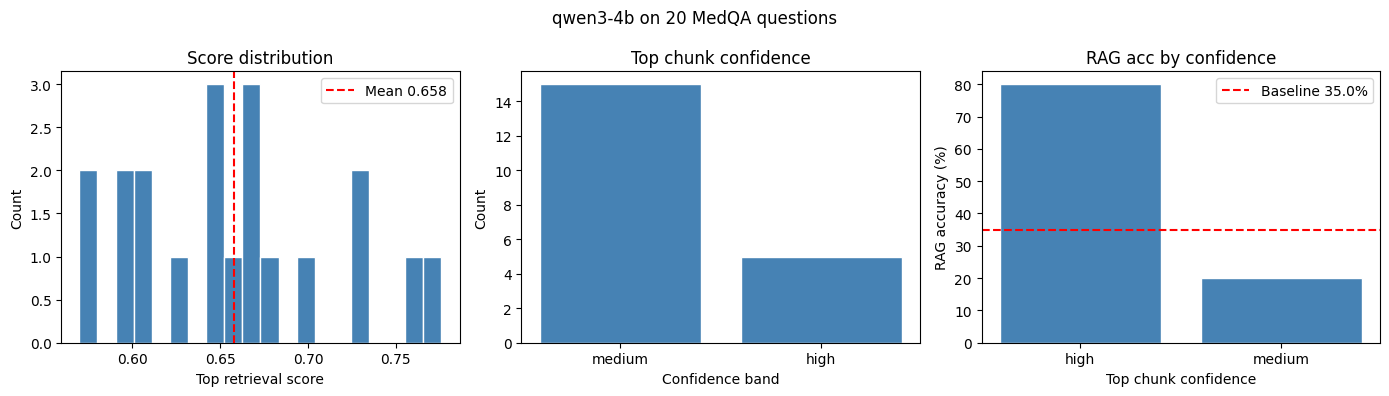

In [22]:
# Retrieval quality
scores = results_df['top_score'].dropna()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(scores, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(scores.mean(), color='red', linestyle='--', label=f'Mean {scores.mean():.3f}')
axes[0].set(xlabel='Top retrieval score', ylabel='Count', title='Score distribution')
axes[0].legend()

conf_counts = results_df['top_confidence'].value_counts()
axes[1].bar(conf_counts.index, conf_counts.values, color='steelblue', edgecolor='white')
axes[1].set(xlabel='Confidence band', ylabel='Count', title='Top chunk confidence')

conf_acc = results_df.groupby('top_confidence')['rag_correct'].mean() * 100
axes[2].bar(conf_acc.index, conf_acc.values, color='steelblue', edgecolor='white')
axes[2].axhline(base_acc, color='red', linestyle='--', label=f'Baseline {base_acc:.1f}%')
axes[2].set(xlabel='Top chunk confidence', ylabel='RAG accuracy (%)', title='RAG acc by confidence')
axes[2].legend()

plt.suptitle(f'{get_default_model_id()} on {len(results_df)} MedQA questions')
plt.tight_layout()
plt.show()

In [23]:
# Cases RAG helped vs hurt
rag_helped = results_df[ results_df['rag_correct'] & ~results_df['base_correct']]
rag_hurt   = results_df[~results_df['rag_correct'] &  results_df['base_correct']]

print(f'RAG helped (correct w/ RAG, wrong w/o): {len(rag_helped)}')
print(f'RAG hurt   (wrong w/ RAG, correct w/o): {len(rag_hurt)}')
print(f'Both correct: {int((results_df["rag_correct"] & results_df["base_correct"]).sum())}')
print(f'Both wrong  : {int((~results_df["rag_correct"] & ~results_df["base_correct"]).sum())}')

if len(rag_helped) > 0:
    print('\nSample questions RAG helped with:')
    display(rag_helped[['question', 'correct', 'top_confidence', 'top_score']].head(3))

RAG helped (correct w/ RAG, wrong w/o): 2
RAG hurt   (wrong w/ RAG, correct w/o): 2
Both correct: 5
Both wrong  : 11

Sample questions RAG helped with:


,question,correct,top_confidence,top_score
1,A 31-year-old female patient presents with sig...,C,medium,0.644512
13,"A 2-hour-old, 3.2 kg (7.0 lb) newborn boy born...",C,high,0.730423


## 7. Save

In [29]:
out = RAG_DIR / 'results.parquet'
results_df.to_parquet(out, index=False)
print(f'Saved -> {out}  ({out.stat().st_size/1024:.0f} KB)')

# Per-model config
model_records = model_summary.set_index('model').to_dict('index')
config = {
    'default_model':    get_default_model_id(),
    'models_evaluated': [m[0] for m in models_to_eval],
    'n_eval_per_model': len(eval_df),
    'top_k':            retriever.top_k,
    'amgrag_ref_f1':    74.1,
    'amgrag_ref_acc':   66.34,
    'amgrag_note':      'GPT-4o-mini backbone, dynamic PubMed KG, MedQA F1 / MedMCQA acc',
    'per_model': {
    tag: {
        'rag_acc':  model_records.get(tag, {}).get('RAG acc%'),
        'base_acc': model_records.get(tag, {}).get('Base acc%'),
        'delta':    model_records.get(tag, {}).get('Delta'),
    }
    for tag, _ in models_to_eval   # unpack the tuple
  },
}
with open(RAG_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'✓ Saved -> {RAG_DIR / "config.json"}')


Saved -> /content/emma/models/rag/results.parquet  (10 KB)
✓ Saved -> /content/emma/models/rag/config.json


In [30]:
# ── COLAB ONLY: copy to Drive ─────────────────────────────────────────────────
import shutil
for f in RAG_DIR.glob('*'):
    shutil.copy(f, DRIVE_OUT / f.name)
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB) -> Drive')
print(f'✓ Done. {DRIVE_OUT}')

  config.json  (0.4 KB) -> Drive
  results.parquet  (10.1 KB) -> Drive
✓ Done. /content/drive/MyDrive/emma/models/rag


## 8. Summary

In [28]:
config = json.loads((RAG_DIR / 'config.json').read_text())

# Best model
best = max(config['per_model'].items(), key=lambda x: x[1]['rag_acc'] or 0)
best_tag, best_stats = best

summary_df = pd.DataFrame([
    {'Item': 'Models evaluated',       'Value': ', '.join(config['models_evaluated'])},
    {'Item': 'Questions per model',    'Value': str(config['n_eval_per_model'])},
    {'Item': 'Best RAG accuracy',      'Value': f"{best_stats['rag_acc']:.1f}%  ({best_tag})"},
    {'Item': 'Best baseline accuracy', 'Value': f"{max(v['base_acc'] or 0 for v in config['per_model'].values()):.1f}%"},
    {'Item': 'Best delta (RAG-base)',  'Value': f"{max(v['delta'] or 0 for v in config['per_model'].values()):+.1f}%"},
    {'Item': 'AMG-RAG F1 (MedQA)',     'Value': f"{config['amgrag_ref_f1']:.1f}%"},
    {'Item': 'AMG-RAG acc (MedMCQA)',  'Value': f"{config['amgrag_ref_acc']:.2f}%"},
    {'Item': 'AMG-RAG note',           'Value': config['amgrag_note']},
])
display(summary_df)

,Item,Value
0,Models evaluated,qwen3-4b
1,Questions per model,20
2,Best RAG accuracy,35.0% (qwen3-4b)
3,Best baseline accuracy,35.0%
4,Best delta (RAG-base),+0.0%
5,AMG-RAG F1 (MedQA),74.1%
6,AMG-RAG acc (MedMCQA),66.34%
7,AMG-RAG note,"GPT-4o-mini backbone, dynamic PubMed KG, MedQA..."


#### Next steps: Notebook 05: Quiz Mode.